In [17]:
''' Solar Particle Flux Analysis using Aditya-L1 SWIS Data
This project analyzes particle flux measurements from the SWIS instrument onboard the Aditya-L1 mission.  
The goal is to explore solar wind particle activity and identify transient disturbances in particle flux.'''
    

' Solar Particle Flux Analysis using Aditya-L1 SWIS Data\nThis project analyzes particle flux measurements from the SWIS instrument onboard the Aditya-L1 mission.  \nThe goal is to explore solar wind particle activity and identify transient disturbances in particle flux.'

In [ ]:
''' 2. Extracting Particle Flux Data
The dataset contains particle flux measurements across multiple energy channels.  
To analyze overall particle activity, we aggregate the flux values across energy bins to create a single time-series signal.'''

In [1]:
import os
os.listdir("../data")

['.DS_Store', 'swis_sample.cdf']

In [2]:
from cdflib import CDF

cdf = CDF("../data/swis_sample.cdf")

info = cdf.cdf_info()

print(info)
print(info.zVariables)

CDFInfo(CDF=PosixPath('/var/folders/hb/dlpcx3vx7f9bldvpf22ly2500000gn/T/tmppgx3bn_5.cdf'), Version='3.9.0', Encoding=6, Majority='Column_major', rVariables=[], zVariables=['epoch_for_cdf_mod', 'energy_center_mod', 'energy_uncer', 'integrated_flux_mod', 'flux_uncer', 'integrated_flux_s15_mod', 'integrated_flux_s16_mod', 'integrated_flux_s17_mod', 'integrated_flux_s18_mod', 'integrated_flux_s19_mod', 'spacecraft_xpos', 'spacecraft_ypos', 'spacecraft_zpos', 'sun_angle_tha2'], Attributes=[{'TITLE': 'Global'}, {'FIELDNAME': 'Variable'}, {'UNITS': 'Variable'}, {'CATDESC': 'Variable'}, {'DEPEND_0': 'Variable'}, {'DEPEND_1': 'Variable'}, {'DEPEND_2': 'Variable'}, {'DISPLAY_TYPE': 'Variable'}, {'FILLVAL': 'Variable'}, {'FORMAT': 'Variable'}, {'LABLAXIS': 'Variable'}, {'LABL_PTR_1': 'Variable'}, {'VALIDMIN': 'Variable'}, {'VALIDMAX': 'Variable'}, {'VAR_TYPE': 'Variable'}, {'SCALETYP': 'Variable'}, {'VAR_NOTES': 'Variable'}, {'AVG_TYPE': 'Variable'}, {'DELTA_PLUS_VAR': 'Variable'}, {'DELTA_MINUS_

In [3]:
import numpy as np

time = cdf.varget("epoch_for_cdf_mod")
energy = cdf.varget("energy_center_mod")
flux = cdf.varget("integrated_flux_mod")
flux_uncer = cdf.varget("flux_uncer")

print("time shape:", np.shape(time))
print("energy shape:", np.shape(energy))
print("flux shape:", np.shape(flux))
print("flux_uncer shape:", np.shape(flux_uncer))

time shape: (8636,)
energy shape: (8636, 50)
flux shape: (8636, 50)
flux_uncer shape: ()


In [4]:
print("First 5 time values:")
print(time[:5])

print("\nFirst 10 energy values:")
print(energy[:10])

print("\nFirst flux row/sample:")
print(flux[0])

First 5 time values:
[6.39401904e+13 6.39401904e+13 6.39401904e+13 6.39401904e+13
 6.39401904e+13]

First 10 energy values:
[[  172.50130344   183.24450193   193.98770042   215.47409739
    226.21729588   236.96049437   258.44689134   279.93328832
    301.4196853    333.64928076   355.13567774   387.3652732
    419.59486866   462.56766262   505.54045657   559.25644901
    612.97244145   666.68843389   731.14762482   806.35001423
    892.29560214   978.24119004  1085.67317492  1193.1051598
   1322.02354166  1461.685122    1612.08990083  1783.98107664
   1977.35864942  2192.22261918  2428.57298592  2686.40974963
   2987.2193073   3309.51526194  3664.04081204  4072.28235458
   4512.75349259  5017.68382153  5565.58694442  6177.94925823
   6865.51396146  7617.53785562  8466.25053618  9400.90880463
  10442.99905797 11603.26449467 12892.44831323 14321.29371214
  15911.28708836 17683.91483888]
 [  172.50130344   183.24450193   193.98770042   215.47409739
    226.21729588   236.96049437   258.4

In [5]:
import pandas as pd
import numpy as np

# If flux is 2D, sum across energy bins
total_flux = np.nansum(flux, axis=1)

df = pd.DataFrame({
    "time": time,
    "total_flux": total_flux
})

df.head()

,time,total_flux
0,6.394019e+13,1.189042e+08
1,6.394019e+13,1.070333e+08
2,6.394019e+13,1.202469e+08
3,6.394019e+13,1.246438e+08
4,6.394019e+13,1.159562e+08


In [6]:
import cdflib

df["time"] = cdflib.cdfepoch.to_datetime(df["time"])

In [7]:
df.head()

,time,total_flux
0,2026-03-08 12:00:23.807,1.189042e+08
1,2026-03-08 12:00:28.807,1.070333e+08
2,2026-03-08 12:00:33.807,1.202469e+08
3,2026-03-08 12:00:38.807,1.246438e+08
4,2026-03-08 12:00:43.807,1.159562e+08


Matplotlib is building the font cache; this may take a moment.


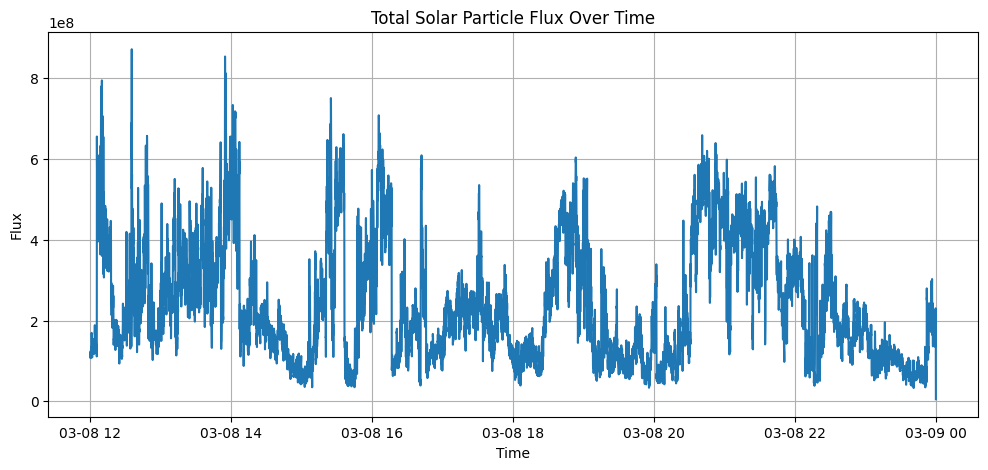

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["time"], df["total_flux"])
plt.title("Total Solar Particle Flux Over Time")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.grid(True)
plt.show()

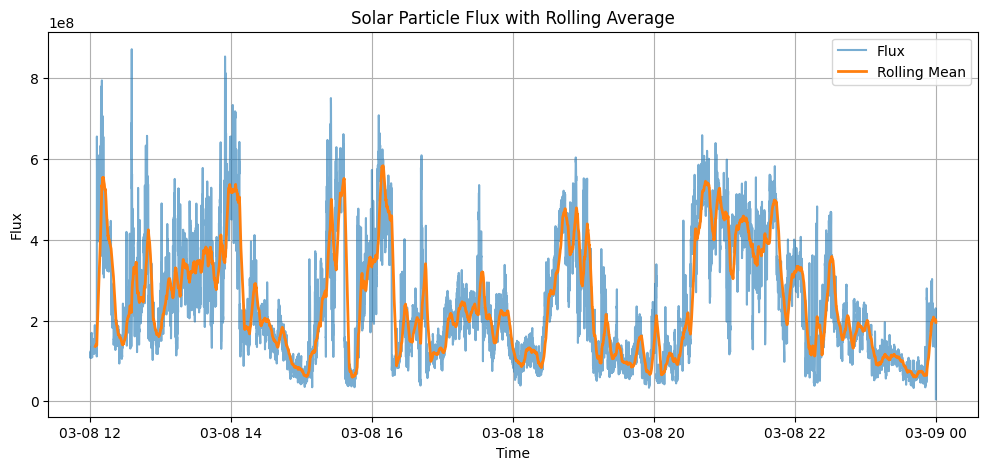

In [9]:
df["flux_ma"] = df["total_flux"].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df["time"], df["total_flux"], alpha=0.6, label="Flux")
plt.plot(df["time"], df["flux_ma"], linewidth=2, label="Rolling Mean")

plt.title("Solar Particle Flux with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df["flux_change"] = df["total_flux"].diff()

threshold = 3 * df["flux_change"].std()

events = df[df["flux_change"].abs() > threshold]

print("Potential disturbances detected:", len(events))
events.head()

Potential disturbances detected: 173


,time,total_flux,flux_ma,flux_change
66,2026-03-08 12:05:53.810,6.559313e+08,1.488864e+08,5.449146e+08
104,2026-03-08 12:09:03.812,6.332104e+08,4.084164e+08,2.040354e+08
113,2026-03-08 12:09:48.812,5.818958e+08,5.051145e+08,-1.407229e+08
114,2026-03-08 12:09:53.812,7.633208e+08,5.180382e+08,1.814250e+08
118,2026-03-08 12:10:13.812,3.601354e+08,5.311382e+08,-4.348646e+08


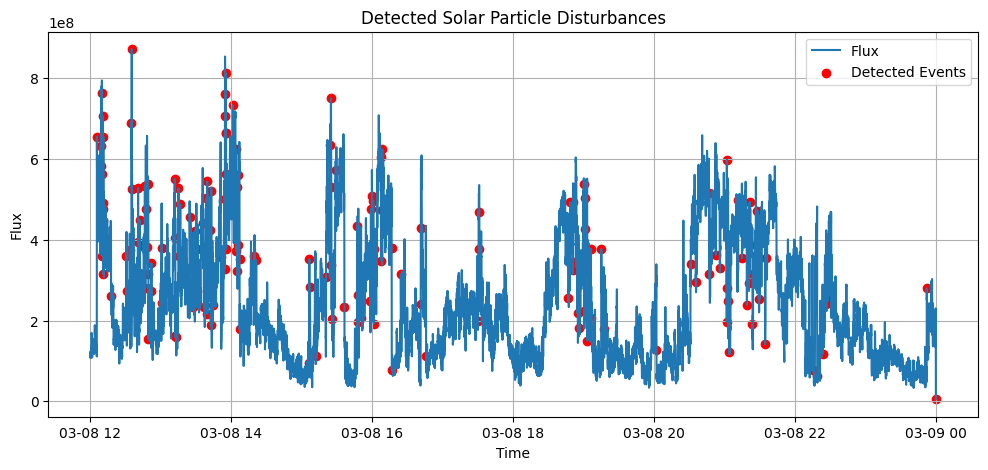

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["time"], df["total_flux"], label="Flux")

plt.scatter(events["time"], events["total_flux"],
            color="red", label="Detected Events")

plt.title("Detected Solar Particle Disturbances")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print("time shape:", time.shape)
print("energy shape:", energy.shape)
print("flux shape:", flux.shape)

time shape: (8636,)
energy shape: (8636, 50)
flux shape: (8636, 50)


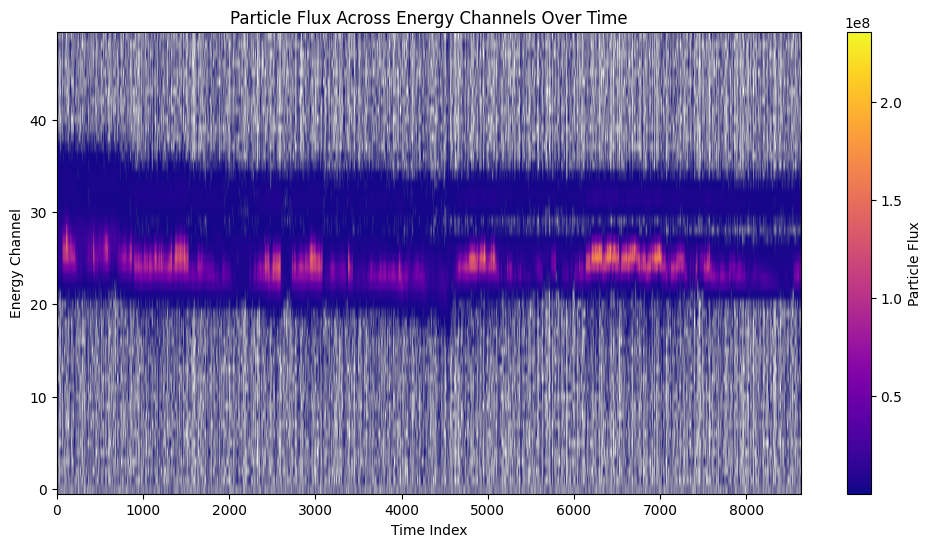

In [13]:
plt.figure(figsize=(12,6))

plt.imshow(
    flux.T,
    aspect='auto',
    origin='lower',
    cmap='plasma'
)

plt.colorbar(label="Particle Flux")

plt.title("Particle Flux Across Energy Channels Over Time")
plt.xlabel("Time Index")
plt.ylabel("Energy Channel")

plt.show()

In [19]:
''' Conclusion

This analysis demonstrates how scientific mission data from Aditya-L1 can be processed and analyzed using Python.  
By extracting particle flux measurements and applying time-series analysis techniques, we identified transient disturbances in solar wind activity.

This project highlights:
- Scientific data processing using CDF format
- Time-series analysis of solar wind particle data
- Visualization of particle flux patterns
- Detection of potential solar disturbance signatures'''

' Conclusion\n\nThis analysis demonstrates how scientific mission data from Aditya-L1 can be processed and analyzed using Python.  \nBy extracting particle flux measurements and applying time-series analysis techniques, we identified transient disturbances in solar wind activity.\n\nThis project highlights:\n- Scientific data processing using CDF format\n- Time-series analysis of solar wind particle data\n- Visualization of particle flux patterns\n- Detection of potential solar disturbance signatures'

In [20]:
plt.savefig("../outputs/flux_timeseries.png", dpi=300)

<Figure size 640x480 with 0 Axes>